# 🕳️ Detección de Huecos en Carreteras

**Dataset:** `taroii/pothole-detection` (Hugging Face)  
**Modelo:** InceptionV3 con Transfer Learning  
**Tarea:** Clasificación binaria — `pothole` vs `no pothole`

---
| Sección | Contenido |
|---------|----------|
| 0 | Configuración del entorno |
| 1 | Imports y reproducibilidad |
| 2 | Carga del dataset |
| **3** | **EDA — Análisis Exploratorio** |
| 4 | Preprocesamiento y DataLoaders |
| 5 | Modelo CNN (InceptionV3) |
| 6 | Fase 1 — Feature Extraction |
| 7 | Fase 2 — Fine-tuning |
| 8 | Evaluación final |
| 9 | Grad-CAM — Explicabilidad |
| 10 | Resumen |


## 0. Configuración del Entorno

Detecta automáticamente la raíz del proyecto y la agrega al `sys.path`.
Funciona tanto en **Google Colab** como en **VS Code / Jupyter local**.


In [34]:
import os, sys

possible_paths = [
    "/content/proyecto_deep_arreglado",
    "/content/proyecto_deep",
    os.getcwd(),
]

for path in possible_paths:
    if os.path.exists(os.path.join(path, "src")):
        os.chdir(path)
        break

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Directorio actual:", os.getcwd())
print("Archivos en raíz:", os.listdir())
print("Archivos en src:", os.listdir("src") if os.path.exists("src") else "No existe src")


Directorio actual: c:\Users\rodri\Desktop\U\2026\2026-1\Deep web\proyecto_deep
Archivos en raíz: ['.git', '.gitignore', '.venv', 'este es el de juan que tomaremos como guia.ipynb', 'models', 'output', 'pothole_detection_FINAL.ipynb', 'README.md', 'requirements.txt', 'setup_kernel.ps1', 'src']
Archivos en src: ['data_loaders.py', 'models.py', 'model_training.py', 'utils.py', 'xai.py', '__init__.py', '__pycache__']


In [35]:
# Descomenta si necesitas instalar dependencias (Colab o entorno nuevo)
# !pip install -r requirements.txt


## 1. Imports y Reproducibilidad

Se fija una semilla global (`SEED=42`) para garantizar que los experimentos
sean **reproducibles**: mismos datos en cada split, misma inicialización del modelo.


In [36]:
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.data_loaders import load_pothole_dataset, create_dataloaders
from src.models import build_pothole_inception, unfreeze_last_layers, count_trainable_parameters
from src.model_training import train_model, evaluate, classification_metrics
from src.utils import plot_training_curves, plot_confusion_matrix, show_predictions
from src.xai import attach_hooks, run_forward, run_backward, compute_gradcam, resize_cam, tensor_to_uint8, overlay_cam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print("GPU     :", torch.cuda.get_device_name(0))


PyTorch : 2.11.0+cpu
Device  : cpu


## 2. Carga del Dataset

El dataset se descarga directamente desde **Hugging Face Hub**.  
`load_pothole_dataset` detecta automáticamente las columnas de imagen y etiqueta.


In [37]:
DATASET_NAME = "taroii/pothole-detection"

info = load_pothole_dataset(DATASET_NAME)
ds   = info.dataset

print("Splits disponibles :", list(ds.keys()))
print("Columna imagen     :", info.image_key)
print("Columna etiqueta   :", info.label_key)
print("Clases             :", info.class_names)
print("Número de clases   :", info.num_classes)
print()
for split in ds.keys():
    print(f"  {split:12s}: {len(ds[split])} imágenes")


Splits disponibles : ['train', 'validation', 'test']
Columna imagen     : image
Columna etiqueta   : label
Clases             : ['no pothole', 'pothole']
Número de clases   : 2

  train       : 200 imágenes
  validation  : 165 imágenes
  test        : 72 imágenes


## 3. EDA — Análisis Exploratorio de Datos

Antes de entrenar cualquier modelo, es esencial **entender el dataset a fondo**.  
Un EDA sólido permite detectar problemas que pueden arruinar el modelo sin que sea evidente.

| # | Análisis | ¿Por qué importa? |
|---|----------|-------------------|
| 3.1 | Información general | Tamaño del dataset, splits y clases disponibles |
| 3.2 | Distribución de clases | Detectar desbalanceo que sesga el entrenamiento |
| 3.3 | Ejemplos visuales | Verificar calidad, diversidad y diferencias visuales |
| 3.3b | **Imagen promedio + mapa de varianza** | Prototipo visual de cada clase |
| 3.4 | Dimensiones de imagen | Confirmar necesidad de resize (299×299) |
| 3.4b | **Análisis de textura y bordes** | Señales de textura diferenciadores entre clases |
| 3.5 | Canales RGB por clase | Señales fotométricas entre clases |
| 3.6 | Brillo promedio por clase | Detectar sesgos de iluminación |
| 3.7 | Calidad del dataset | Imágenes corruptas o duplicados entre splits |
| 3.8 | **Preview de data augmentation** | Verificar que las transformaciones son realistas |
| — | **Resumen y conclusiones** | Síntesis de hallazgos clave |


### 3.1 Información General

Resumen de la estructura del dataset: cuántas imágenes hay en cada split  
y qué proporción representan del total.


In [38]:
import pandas as pd
from collections import Counter
from hashlib import md5

os.makedirs("output", exist_ok=True)

# Paleta de colores consistente para todo el EDA
PALETTE     = ["#4CAF50", "#F44336", "#2196F3", "#FF9800"]
CLASS_COLORS = {name: PALETTE[i % len(PALETTE)]
                for i, name in enumerate(info.class_names)}

print("=" * 60)
print("   POTHOLE DETECTION DATASET — RESUMEN GENERAL")
print("=" * 60)
print(f"  Fuente   : {DATASET_NAME}")
print(f"  Clases   : {info.class_names}  ({info.num_classes} clases)")
print(f"  Img key  : '{info.image_key}'  |  Label key: '{info.label_key}'")
print()

total = sum(len(ds[s]) for s in ds.keys())
print(f"  {'Split':<14} {'Imágenes':>9}   {'% total':>8}   Proporción")
print("  " + "-" * 50)
for split in ds.keys():
    n   = len(ds[split])
    pct = 100 * n / total
    bar = "█" * int(pct / 2)
    print(f"  {split:<14} {n:>9}   {pct:>7.1f}%   {bar}")
print(f"  {'TOTAL':<14} {total:>9}")
print("=" * 60)


   POTHOLE DETECTION DATASET — RESUMEN GENERAL
  Fuente   : taroii/pothole-detection
  Clases   : ['no pothole', 'pothole']  (2 clases)
  Img key  : 'image'  |  Label key: 'label'

  Split           Imágenes    % total   Proporción
  --------------------------------------------------
  train                200      45.8%   ██████████████████████
  validation           165      37.8%   ██████████████████
  test                  72      16.5%   ████████
  TOTAL                437


### 3.2 Distribución de Clases por Split

Un dataset **desbalanceado** hace que el modelo aprenda a "adivinar" la clase mayoritaria.  
Se analiza el balance en todos los splits y se calcula el **ratio de desbalanceo**.

> ✅ `ratio < 1.5x` → Balanceado  
> ⚠️ `1.5x – 3x` → Leve desbalanceo  
> 🔴 `> 3x` → Desbalanceado — considerar *class weights* o *oversampling*


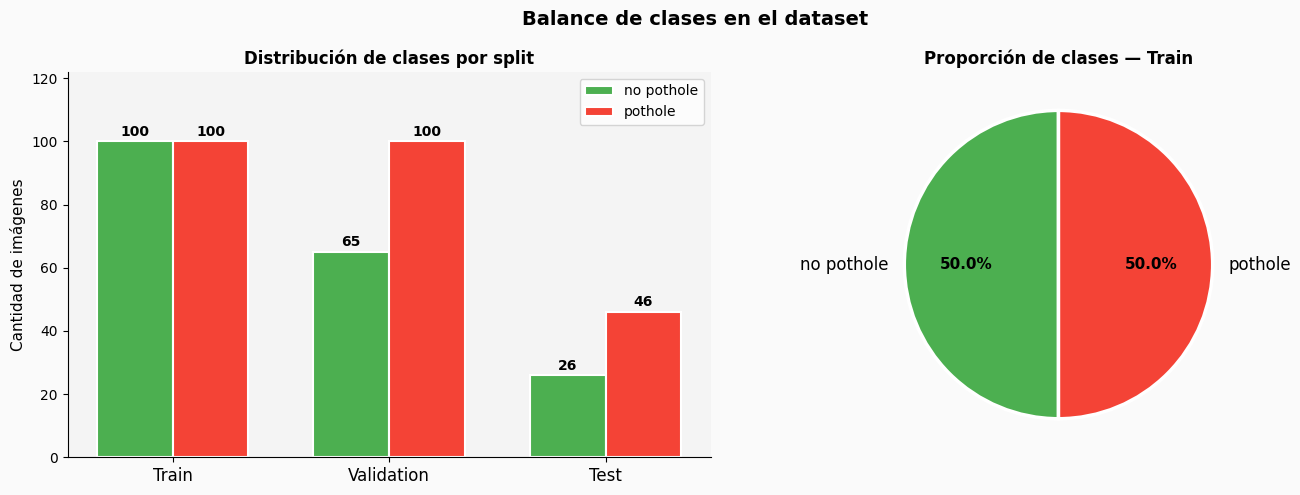


📊 Diagnóstico de balanceo por split:
  train        ✅ Balanceado                    ratio=1.00x  {'no pothole': np.int64(100), 'pothole': np.int64(100)}
  validation   ⚠️  Leve desbalanceo            ratio=1.54x  {'no pothole': np.int64(65), 'pothole': np.int64(100)}
  test         ⚠️  Leve desbalanceo            ratio=1.77x  {'no pothole': np.int64(26), 'pothole': np.int64(46)}


In [39]:
# Contar distribución por split y clase
dist = {}
for split in ds.keys():
    labels = ds[split][info.label_key]
    if isinstance(labels[0], str):
        counts = Counter(labels)
    else:
        counts = Counter(info.class_names[int(x)] for x in labels)
    dist[split] = {cls: counts.get(cls, 0) for cls in info.class_names}

df_dist = pd.DataFrame(dist).T  # filas=splits, columnas=clases

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#FAFAFA")
for ax in axes:
    ax.set_facecolor("#F4F4F4")

# ─── Barras agrupadas ─────────────────────────────────────────────────────────
n_cls  = len(info.class_names)
x      = np.arange(len(df_dist.index))
w      = 0.7 / n_cls
for i, cls in enumerate(info.class_names):
    offset = (i - (n_cls - 1) / 2) * w
    bars = axes[0].bar(
        x + offset, df_dist[cls], w,
        label=cls, color=CLASS_COLORS[cls],
        edgecolor="white", linewidth=1.5
    )
    for bar, val in zip(bars, df_dist[cls]):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            str(int(val)), ha="center", va="bottom",
            fontsize=10, fontweight="bold"
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels([s.capitalize() for s in df_dist.index], fontsize=12)
axes[0].set_ylabel("Cantidad de imágenes", fontsize=11)
axes[0].set_title("Distribución de clases por split", fontweight="bold", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].set_ylim(0, df_dist.values.max() * 1.22)

# ─── Pie chart del split train ────────────────────────────────────────────────
train_counts = df_dist.loc["train"]
wedges, texts, autotexts = axes[1].pie(
    train_counts.values,
    labels=train_counts.index,
    colors=[CLASS_COLORS[c] for c in train_counts.index],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold")
axes[1].set_title("Proporción de clases — Train", fontweight="bold", fontsize=12)

plt.suptitle("Balance de clases en el dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("output/eda_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

# Diagnóstico
print("\n📊 Diagnóstico de balanceo por split:")
for split in df_dist.index:
    row   = df_dist.loc[split]
    ratio = row.max() / row.min() if row.min() > 0 else float("inf")
    tag   = "✅ Balanceado" if ratio < 1.5 else ("⚠️  Leve desbalanceo" if ratio < 3 else "🔴 Desbalanceado")
    print(f"  {split:12s} {tag:30s}  ratio={ratio:.2f}x  {dict(row.astype(int))}")


### 3.3 Ejemplos Visuales por Clase

Inspeccionar imágenes reales permite verificar:
- **Variabilidad** de ángulos, iluminación y condiciones climáticas
- **Calidad** general de las imágenes y posibles errores de etiquetado
- Qué características visuales distinguen una clase de la otra

Las imágenes de **huecos** suelen tener bordes irregulares, depresiones oscuras y  
texturas más rugosas que el pavimento normal.


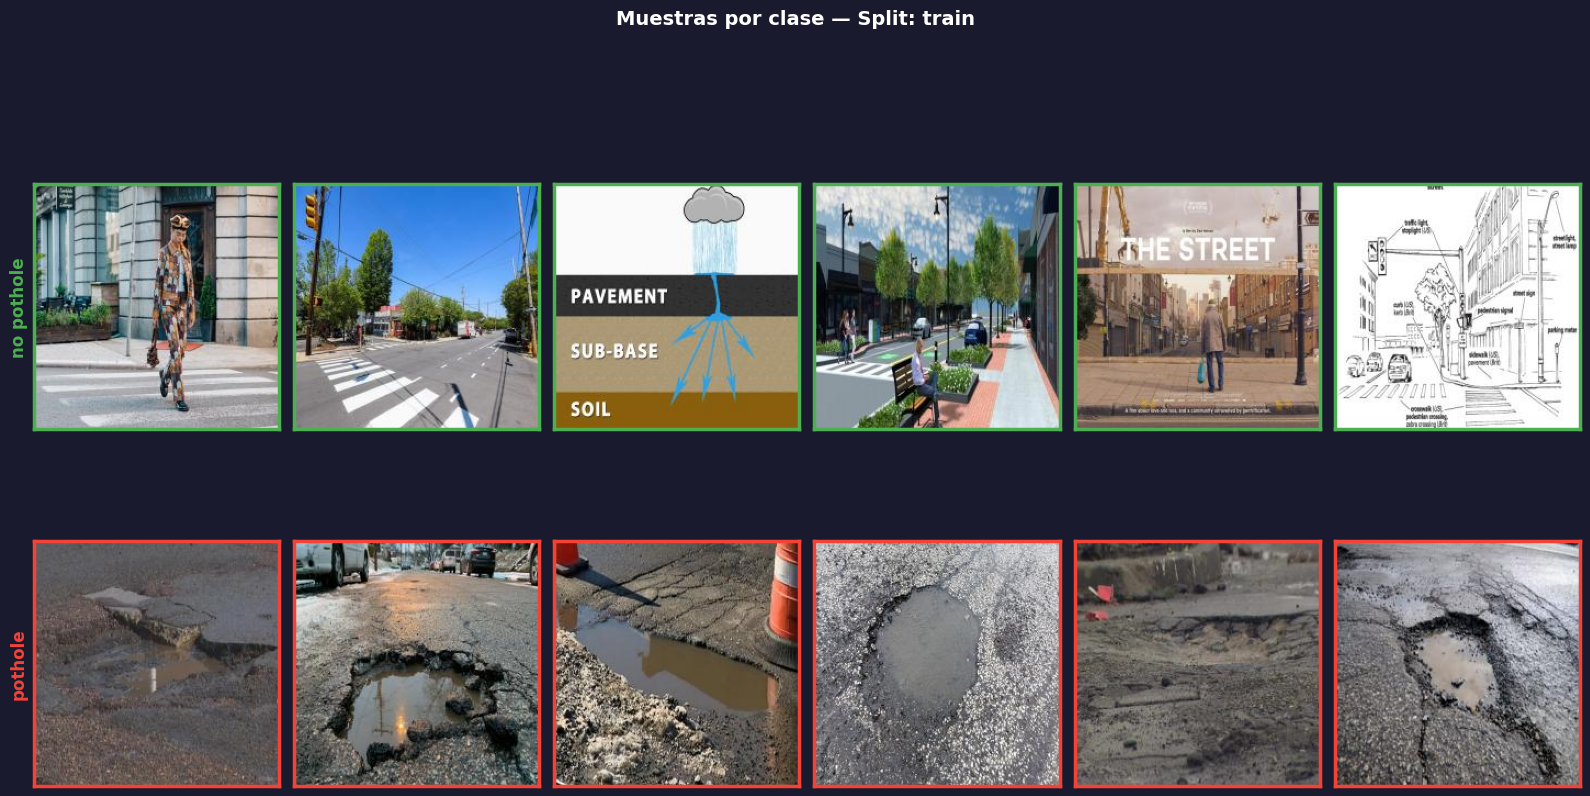

In [40]:
n_cols    = 6
split_vis = "train"

# Índices por clase
indices_por_clase = {cls: [] for cls in info.class_names}
for i, label in enumerate(ds[split_vis][info.label_key]):
    cls = label if isinstance(label, str) else info.class_names[int(label)]
    indices_por_clase[cls].append(i)

fig, axes = plt.subplots(
    info.num_classes, n_cols,
    figsize=(16, 4.5 * info.num_classes)
)
fig.patch.set_facecolor("#1A1A2E")

# Normalizar axes a 2D
if info.num_classes == 1:
    axes = axes.reshape(1, -1)

for row, cls in enumerate(info.class_names):
    disponibles = indices_por_clase[cls]
    muestra     = random.sample(disponibles, min(n_cols, len(disponibles)))
    for col in range(n_cols):
        ax = axes[row][col]
        ax.set_facecolor("#1A1A2E")
        if col < len(muestra):
            img = ds[split_vis][muestra[col]][info.image_key]
            ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(CLASS_COLORS[cls])
            spine.set_linewidth(2.5)
        if col == 0:
            ax.set_ylabel(
                cls, fontsize=12, fontweight="bold",
                color=CLASS_COLORS[cls]
            )

fig.suptitle(
    f"Muestras por clase — Split: {split_vis}",
    fontsize=14, fontweight="bold", color="white", y=1.01
)
plt.tight_layout()
plt.savefig(
    "output/eda_ejemplos_por_clase.png", dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()


### 3.3b Imagen Promedio por Clase

La **imagen promedio** (media píxel a píxel de N imágenes por clase) revela el  
"prototipo visual" de cada clase: qué aspecto tiene un hueco *típico* vs pavimento *típico*.

> Las zonas brillantes indican regiones de alto consenso (muchas imágenes coinciden).  
> Las zonas oscuras/borrosas indican alta variabilidad entre muestras.

Esta visualización es clave para confirmar que las clases tienen **firmas visuales distintas**.


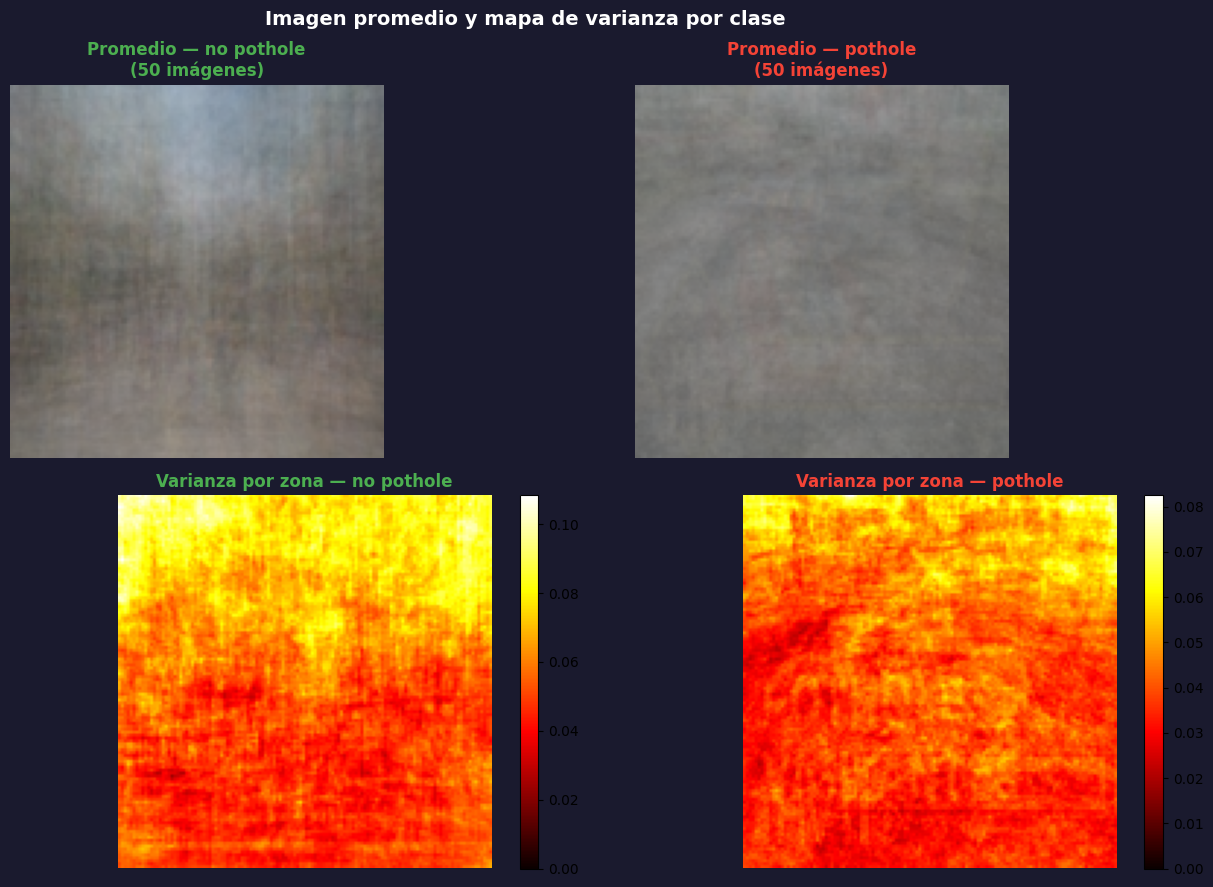

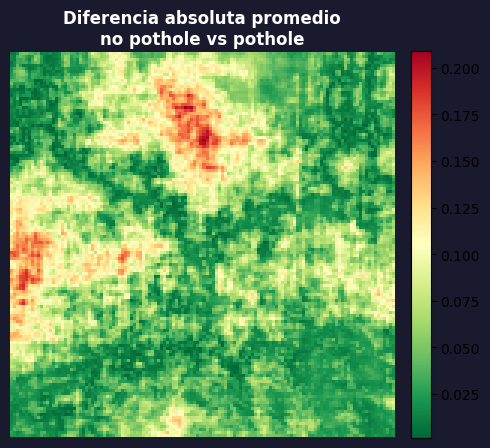


  Diferencia promedio máxima entre clases: 0.2091
  Diferencia promedio media   entre clases: 0.0560
  ➜ Alta separabilidad visual entre clases.


In [41]:
# ─── Imagen promedio por clase ───────────────────────────────────────────────
# Usamos las mismas muestras de 3.3 (indices_por_clase ya definido)
SIZE_AVG = 128  # resolución para el promedio (más rápido que 299)
N_AVG    = min(50, min(len(indices_por_clase[c]) for c in info.class_names))

avg_imgs    = {}
var_maps    = {}

for cls in info.class_names:
    idxs_cls = random.sample(indices_por_clase[cls], N_AVG)
    stack = np.stack([
        np.array(
            ds[split_vis][i][info.image_key].convert("RGB").resize((SIZE_AVG, SIZE_AVG)),
            dtype=np.float32
        ) / 255.0
        for i in idxs_cls
    ])  # (N, H, W, 3)
    avg_imgs[cls] = stack.mean(axis=0)
    var_maps[cls] = stack.var(axis=0).mean(axis=-1)  # varianza media entre canales

fig, axes = plt.subplots(2, len(info.class_names), figsize=(7 * len(info.class_names), 9))
fig.patch.set_facecolor("#1A1A2E")
if len(info.class_names) == 1:
    axes = axes.reshape(2, 1)

for col, cls in enumerate(info.class_names):
    # Fila 0: imagen promedio
    axes[0][col].imshow(np.clip(avg_imgs[cls], 0, 1))
    axes[0][col].set_title(
        f"Promedio — {cls}\n({N_AVG} imágenes)",
        color=CLASS_COLORS[cls], fontweight="bold", fontsize=12
    )
    axes[0][col].axis("off")

    # Fila 1: mapa de varianza (zonas con alta variabilidad entre imágenes)
    im = axes[1][col].imshow(var_maps[cls], cmap="hot", vmin=0)
    axes[1][col].set_title(
        f"Varianza por zona — {cls}",
        color=CLASS_COLORS[cls], fontweight="bold", fontsize=12
    )
    axes[1][col].axis("off")
    plt.colorbar(im, ax=axes[1][col], fraction=0.046, pad=0.04)

plt.suptitle(
    "Imagen promedio y mapa de varianza por clase",
    fontsize=14, fontweight="bold", color="white"
)
plt.tight_layout()
plt.savefig(
    "output/eda_imagen_promedio.png", dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()

# Diferencia entre promedios (qué zonas difieren más entre clases)
if len(info.class_names) == 2:
    cls_a, cls_b = info.class_names
    diff = np.abs(avg_imgs[cls_a] - avg_imgs[cls_b]).mean(axis=-1)
    fig2, ax2 = plt.subplots(1, 1, figsize=(5, 5))
    fig2.patch.set_facecolor("#1A1A2E")
    ax2.set_facecolor("#1A1A2E")
    im2 = ax2.imshow(diff, cmap="RdYlGn_r")
    ax2.set_title(
        f"Diferencia absoluta promedio\n{cls_a} vs {cls_b}",
        color="white", fontweight="bold"
    )
    ax2.axis("off")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(
        "output/eda_diferencia_promedio.png", dpi=150, bbox_inches="tight",
        facecolor=fig2.get_facecolor()
    )
    plt.show()
    print(f"\n  Diferencia promedio máxima entre clases: {diff.max():.4f}")
    print(f"  Diferencia promedio media   entre clases: {diff.mean():.4f}")
    print(f"  ➜ {'Alta' if diff.mean() > 0.05 else 'Baja'} separabilidad visual entre clases.")


### 3.4 Dimensiones de Imagen

**InceptionV3** requiere exactamente **299 × 299 px**.  
Se verifica si las imágenes originales tienen dimensiones uniformes o variables,  
y si el ratio de aspecto (ancho/alto) se aleja de 1:1 (lo cual distorsionaría el resize).


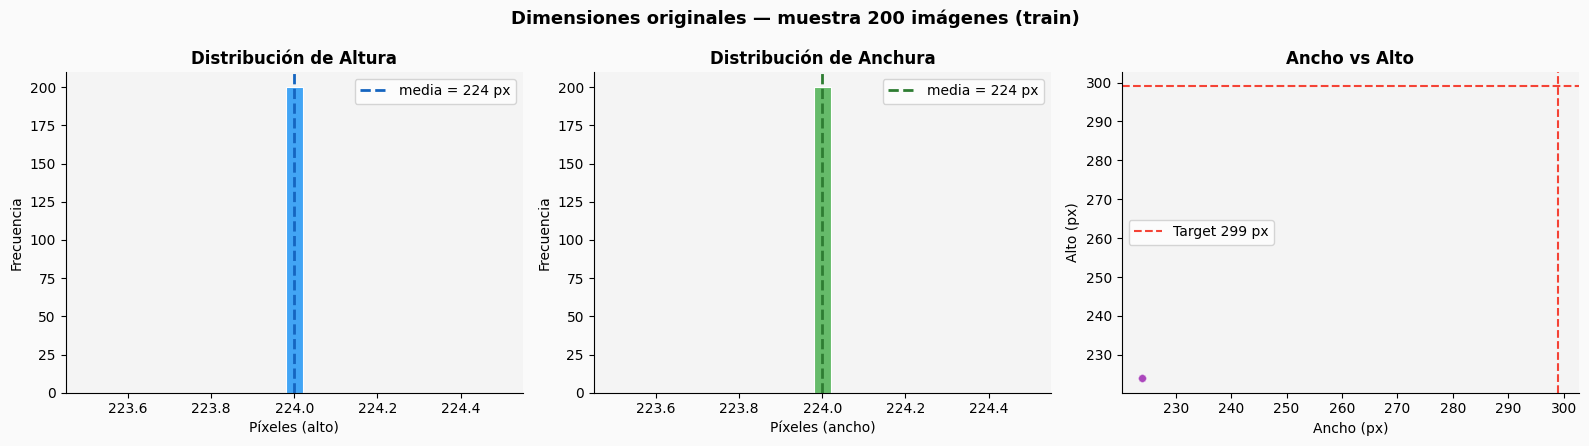

  Ancho  — media: 224.0 px | std: 0.0 px | rango: [224, 224]
  Alto   — media: 224.0 px | std: 0.0 px | rango: [224, 224]
  Ratio  — media: 1.000 | cuadradas (±5%): 200 / 200

  ➜ Resize a 299×299 es formalidad — las dimensiones son casi uniformes.


In [42]:
n_samples = min(200, len(ds["train"]))
idxs_dim  = random.sample(range(len(ds["train"])), n_samples)

widths, heights = [], []
for idx in idxs_dim:
    img = ds["train"][idx][info.image_key]
    widths.append(img.size[0])
    heights.append(img.size[1])

widths  = np.array(widths)
heights = np.array(heights)
ratios  = widths / heights

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor("#FAFAFA")
for ax in axes:
    ax.set_facecolor("#F4F4F4")
    ax.spines[["top", "right"]].set_visible(False)

# Histograma de altura
axes[0].hist(heights, bins=25, color="#42A5F5", edgecolor="white", linewidth=0.8)
axes[0].axvline(heights.mean(), color="#1565C0", linestyle="--", linewidth=2,
                label=f"media = {heights.mean():.0f} px")
axes[0].set_title("Distribución de Altura", fontweight="bold")
axes[0].set_xlabel("Píxeles (alto)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Histograma de anchura
axes[1].hist(widths, bins=25, color="#66BB6A", edgecolor="white", linewidth=0.8)
axes[1].axvline(widths.mean(), color="#2E7D32", linestyle="--", linewidth=2,
                label=f"media = {widths.mean():.0f} px")
axes[1].set_title("Distribución de Anchura", fontweight="bold")
axes[1].set_xlabel("Píxeles (ancho)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

# Scatter alto vs ancho
axes[2].scatter(widths, heights, alpha=0.4, color="#AB47BC", s=30,
                edgecolors="white", linewidths=0.3)
axes[2].axhline(299, color="#F44336", linestyle="--", linewidth=1.5,
                label="Target 299 px")
axes[2].axvline(299, color="#F44336", linestyle="--", linewidth=1.5)
axes[2].set_title("Ancho vs Alto", fontweight="bold")
axes[2].set_xlabel("Ancho (px)")
axes[2].set_ylabel("Alto (px)")
axes[2].legend()

plt.suptitle(
    f"Dimensiones originales — muestra {n_samples} imágenes (train)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("output/eda_dimensiones.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"  Ancho  — media: {widths.mean():.1f} px | std: {widths.std():.1f} px | rango: [{widths.min()}, {widths.max()}]")
print(f"  Alto   — media: {heights.mean():.1f} px | std: {heights.std():.1f} px | rango: [{heights.min()}, {heights.max()}]")
print(f"  Ratio  — media: {ratios.mean():.3f} | cuadradas (±5%): {(np.abs(ratios - 1) < 0.05).sum()} / {n_samples}")
variando = widths.std() > 10 or heights.std() > 10
print(f"\n  ➜ Resize a 299×299 {'es necesario' if variando else 'es formalidad'} — las dimensiones {'varían' if variando else 'son casi uniformes'}.")


### 3.4b Análisis de Textura y Bordes

La textura es una de las señales más discriminativas entre huecos y pavimento normal:

| Métrica | Descripción | ¿Qué esperamos? |
|---------|-------------|------------------|
| **Varianza de píxeles** | Dispersión de intensidades en la imagen | Huecos: mayor varianza (texturas irregulares) |
| **Densidad de bordes** | Media del gradiente Sobel | Huecos: más bordes (grietas, bordes del hueco) |
| **Entropía** | Complejidad/información en la distribución de píxeles | Huecos: mayor entropía |

> Una alta diferencia en estas métricas confirma que la CNN podrá usar  
> **detectores de textura y bordes** internos para clasificar correctamente.


  Métricas de textura por clase (media ± std):
  Clase                    Varianza   Bordes (Sobel)     Entropía
  ----------------------------------------------------------------
  no pothole           3453.9±1243.8    107.52±26.21   7.4287±0.6273
  pothole              2260.6±1197.7     86.94±26.19   7.2414±0.4265


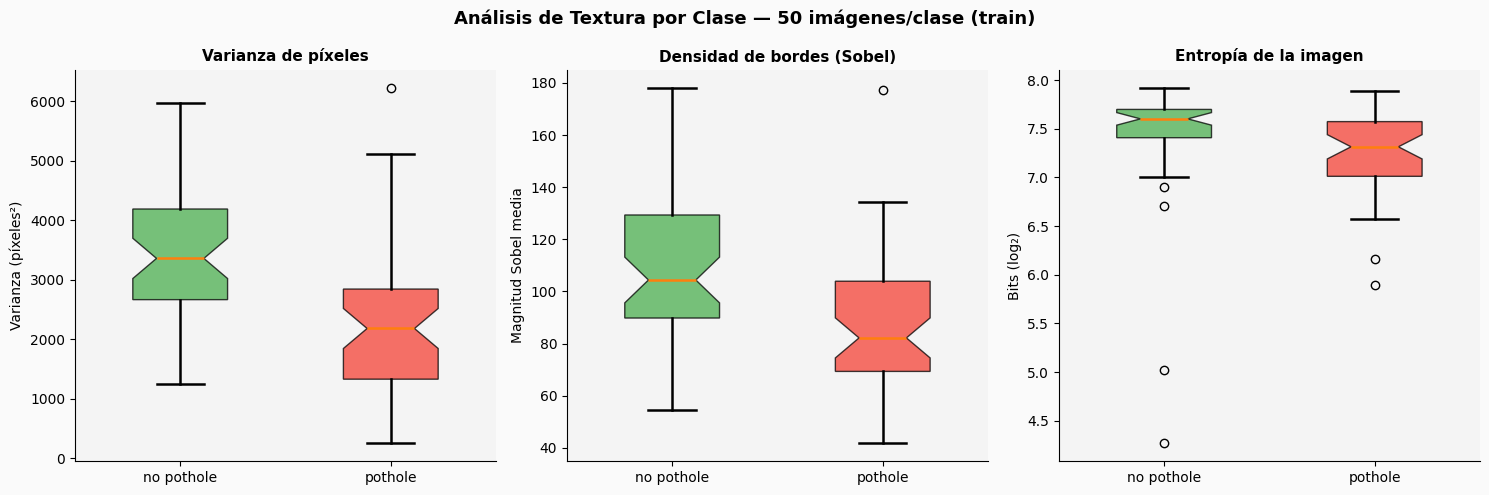

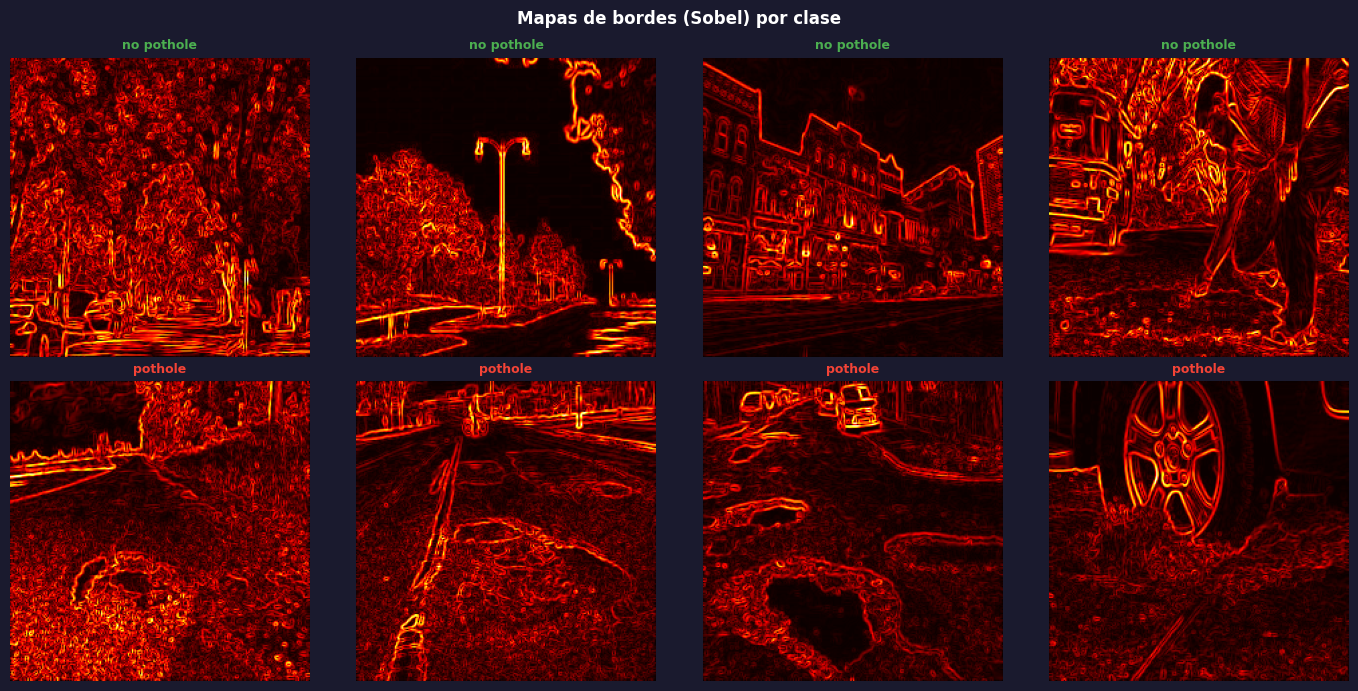

In [43]:
import cv2

N_TEX = min(50, min(len(indices_por_clase[c]) for c in info.class_names))

tex_stats = {cls: {"varianza": [], "bordes": [], "entropia": []}
             for cls in info.class_names}

for cls in info.class_names:
    sample_idxs = random.sample(indices_por_clase[cls], N_TEX)
    for idx in sample_idxs:
        arr = np.array(ds[split_vis][idx][info.image_key].convert("L"), dtype=np.float32)

        # Varianza de píxeles
        tex_stats[cls]["varianza"].append(float(arr.var()))

        # Densidad de bordes (Sobel)
        arr_u8  = arr.astype(np.uint8)
        sobelx  = cv2.Sobel(arr_u8, cv2.CV_64F, 1, 0, ksize=3)
        sobely  = cv2.Sobel(arr_u8, cv2.CV_64F, 0, 1, ksize=3)
        tex_stats[cls]["bordes"].append(float(np.sqrt(sobelx**2 + sobely**2).mean()))

        # Entropía del histograma de píxeles
        hist, _ = np.histogram(arr.ravel(), bins=256, range=(0, 256))
        prob     = hist / hist.sum()
        prob     = prob[prob > 0]
        tex_stats[cls]["entropia"].append(float(-np.sum(prob * np.log2(prob))))

# Tabla resumen
print("  Métricas de textura por clase (media ± std):")
print(f"  {'Clase':<18} {'Varianza':>14} {'Bordes (Sobel)':>16} {'Entropía':>12}")
print("  " + "-" * 64)
for cls in info.class_names:
    v   = tex_stats[cls]["varianza"]
    b   = tex_stats[cls]["bordes"]
    e   = tex_stats[cls]["entropia"]
    print(f"  {cls:<18} "
          f"{np.mean(v):>8.1f}±{np.std(v):<4.1f} "
          f"{np.mean(b):>9.2f}±{np.std(b):<5.2f} "
          f"{np.mean(e):>8.4f}±{np.std(e):<.4f}")

# Boxplots
metricas = ["varianza", "bordes", "entropia"]
titulos  = ["Varianza de píxeles", "Densidad de bordes (Sobel)", "Entropía de la imagen"]
ylabels  = ["Varianza (píxeles²)", "Magnitud Sobel media", "Bits (log₂)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#FAFAFA")

for ax, met, tit, yl in zip(axes, metricas, titulos, ylabels):
    ax.set_facecolor("#F4F4F4")
    ax.spines[["top", "right"]].set_visible(False)
    data_bp = [tex_stats[cls][met] for cls in info.class_names]
    bp = ax.boxplot(data_bp, labels=info.class_names,
                    patch_artist=True, notch=True, widths=0.45)
    for patch, cls in zip(bp["boxes"], info.class_names):
        patch.set_facecolor(CLASS_COLORS[cls]); patch.set_alpha(0.75)
    for el in ["whiskers", "caps", "medians"]:
        plt.setp(bp[el], linewidth=1.8)
    ax.set_title(tit, fontweight="bold", fontsize=11)
    ax.set_ylabel(yl, fontsize=10)

plt.suptitle(
    f"Análisis de Textura por Clase — {N_TEX} imágenes/clase (train)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("output/eda_textura.png", dpi=150, bbox_inches="tight")
plt.show()

# Mapa de bordes de ejemplo por clase
fig3, axes3 = plt.subplots(2, 4, figsize=(14, 7))
fig3.patch.set_facecolor("#1A1A2E")
for row, cls in enumerate(info.class_names):
    muestra_tex = random.sample(indices_por_clase[cls], min(4, len(indices_por_clase[cls])))
    for col, idx in enumerate(muestra_tex):
        arr_u8 = np.array(ds[split_vis][idx][info.image_key].convert("L"), dtype=np.uint8)
        sx = cv2.Sobel(arr_u8, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(arr_u8, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        mag = (mag / mag.max() * 255).astype(np.uint8) if mag.max() > 0 else mag
        axes3[row][col].imshow(mag, cmap="hot")
        axes3[row][col].set_title(cls, color=CLASS_COLORS[cls], fontsize=9, fontweight="bold")
        axes3[row][col].axis("off")

plt.suptitle("Mapas de bordes (Sobel) por clase",
             fontsize=12, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig("output/eda_mapas_bordes.png", dpi=150, bbox_inches="tight",
            facecolor=fig3.get_facecolor())
plt.show()


### 3.5 Canales RGB por Clase

Los **huecos** tienden a tener tonos más oscuros y grises (asfalto deteriorado,  
sombras internas) mientras que el **pavimento normal** puede ser más claro y uniforme.  
Analizar la distribución de intensidad por canal y clase permite verificar si existen  
**señales fotométricas** que el modelo puede aprender a explotar.

> Si las distribuciones de ambas clases están muy solapadas en los tres canales,  
> el modelo necesitará aprender patrones de **textura o forma**, no solo de color.


  Intensidad media por canal RGB y clase (rango 0–1):
  Clase                 Canal R    Canal G    Canal B
  ----------------------------------------------------
  no pothole             0.4748     0.4561     0.4349
  pothole                0.4760     0.4695     0.4579


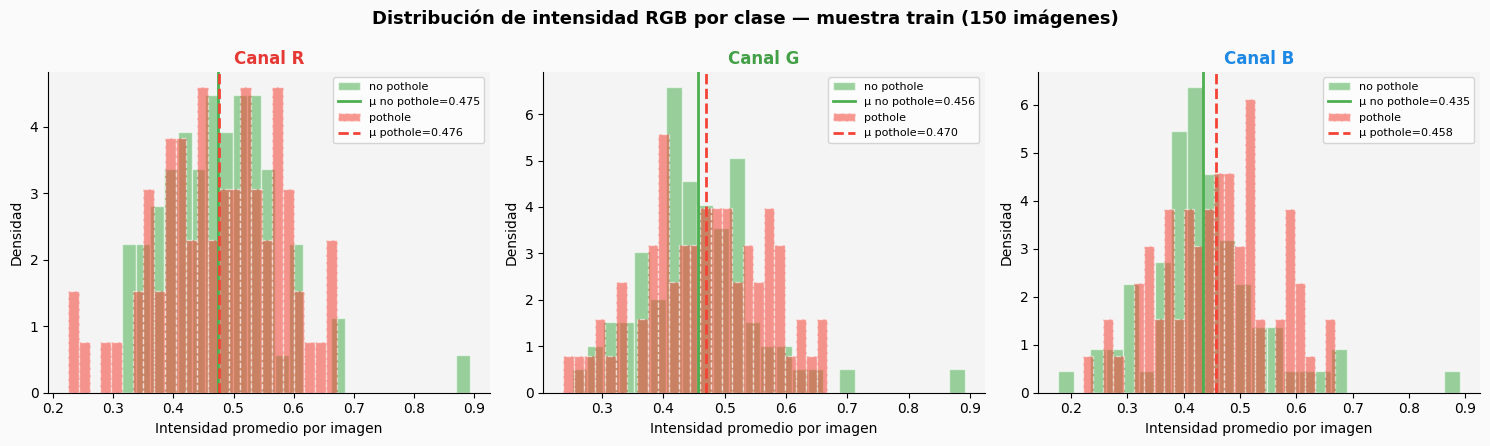

In [44]:
n_rgb      = min(150, len(ds["train"]))
idxs_rgb   = random.sample(range(len(ds["train"])), n_rgb)
canal_stats = {cls: {"R": [], "G": [], "B": []} for cls in info.class_names}

for idx in idxs_rgb:
    item = ds["train"][idx]
    arr  = np.array(item[info.image_key].convert("RGB")) / 255.0
    cls  = item[info.label_key]
    if not isinstance(cls, str):
        cls = info.class_names[int(cls)]
    canal_stats[cls]["R"].append(arr[:, :, 0].mean())
    canal_stats[cls]["G"].append(arr[:, :, 1].mean())
    canal_stats[cls]["B"].append(arr[:, :, 2].mean())

# Tabla de medias
print("  Intensidad media por canal RGB y clase (rango 0–1):")
print(f"  {'Clase':<18} {'Canal R':>10} {'Canal G':>10} {'Canal B':>10}")
print("  " + "-" * 52)
for cls in info.class_names:
    r = np.mean(canal_stats[cls]["R"])
    g = np.mean(canal_stats[cls]["G"])
    b = np.mean(canal_stats[cls]["B"])
    print(f"  {cls:<18} {r:>10.4f} {g:>10.4f} {b:>10.4f}")

# Histogramas superpuestos por canal
canales_nombre = ["R", "G", "B"]
canales_color  = ["#E53935", "#43A047", "#1E88E5"]
linestyles     = ["-", "--", ":", "-."]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor("#FAFAFA")

for ax, canal, c_rgb in zip(axes, canales_nombre, canales_color):
    ax.set_facecolor("#F4F4F4")
    for i, cls in enumerate(info.class_names):
        datos = canal_stats[cls][canal]
        ax.hist(datos, bins=25, alpha=0.55, color=CLASS_COLORS[cls],
                linestyle=linestyles[i], edgecolor="white",
                label=cls, density=True)
        ax.axvline(np.mean(datos), color=CLASS_COLORS[cls],
                   linestyle=linestyles[i], linewidth=2,
                   label=f"\u03bc {cls[:10]}={np.mean(datos):.3f}")
    ax.set_title(f"Canal {canal}", fontweight="bold", fontsize=12, color=c_rgb)
    ax.set_xlabel("Intensidad promedio por imagen")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle(
    f"Distribución de intensidad RGB por clase — muestra train ({n_rgb} imágenes)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("output/eda_rgb_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.6 Brillo Promedio por Clase

El **brillo medio** (imagen convertida a escala de grises) permite detectar:
- Sesgos de iluminación entre clases (huecos más oscuros que pavimento limpio)
- Imágenes nocturnas o en condiciones adversas
- La utilidad de técnicas de normalización de brillo

Se muestran además las **imágenes extremas** del dataset: las 4 más oscuras y las 4 más brillantes.


  Estadísticas de brillo (0–255) por clase:
  Clase                 Media     Std     Min     Max   Mediana
  ----------------------------------------------------------
  no pothole            120.2    26.6    62.9   233.9     117.3
  pothole               121.3    24.3    59.9   170.5     123.2


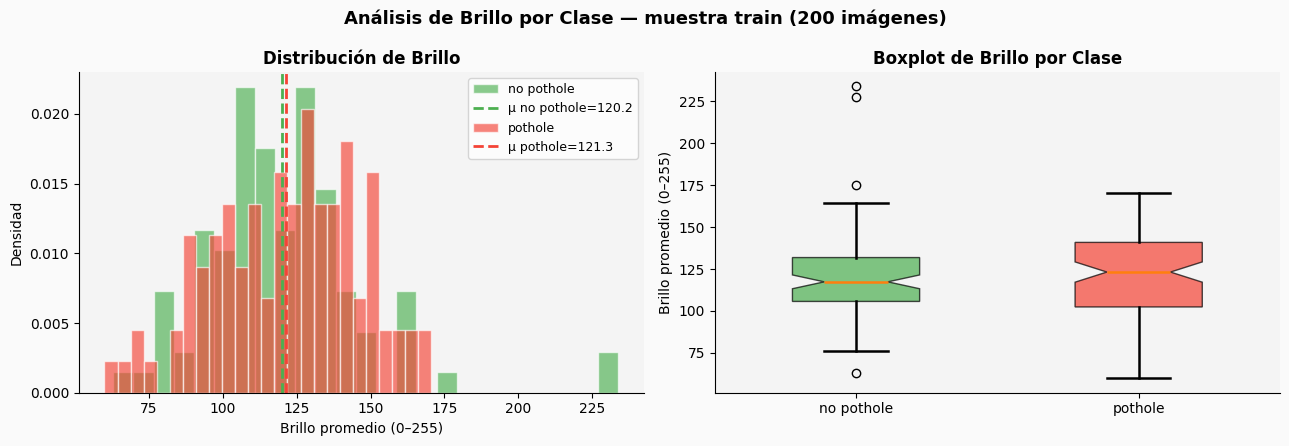

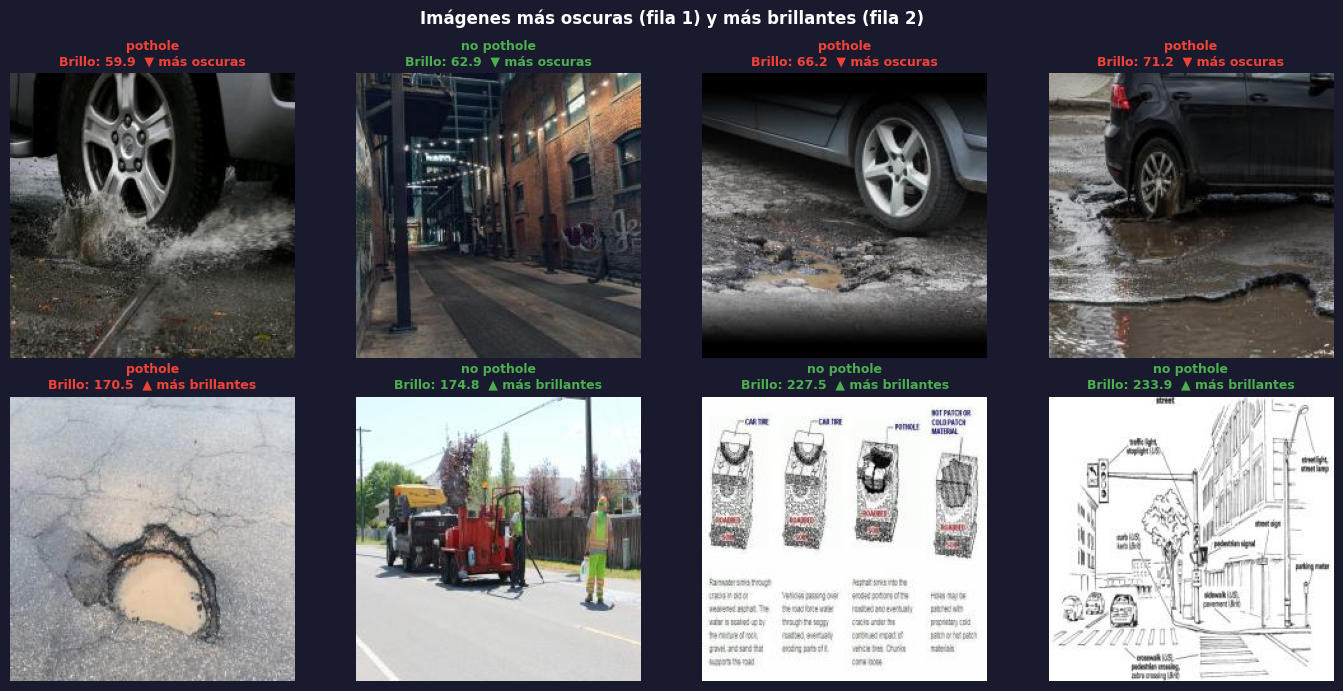

In [45]:
n_brillo      = min(200, len(ds["train"]))
idxs_brillo   = random.sample(range(len(ds["train"])), n_brillo)
brillo_por_cls = {cls: [] for cls in info.class_names}

for idx in idxs_brillo:
    item = ds["train"][idx]
    b    = np.array(item[info.image_key].convert("L")).mean()
    cls  = item[info.label_key]
    if not isinstance(cls, str):
        cls = info.class_names[int(cls)]
    brillo_por_cls[cls].append(b)

print("  Estadísticas de brillo (0–255) por clase:")
print(f"  {'Clase':<18} {'Media':>8} {'Std':>7} {'Min':>7} {'Max':>7} {'Mediana':>9}")
print("  " + "-" * 58)
for cls in info.class_names:
    b = brillo_por_cls[cls]
    print(f"  {cls:<18} {np.mean(b):>8.1f} {np.std(b):>7.1f} "
          f"{np.min(b):>7.1f} {np.max(b):>7.1f} {np.median(b):>9.1f}")

# ─── Histograma + Boxplot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#FAFAFA")
for ax in axes:
    ax.set_facecolor("#F4F4F4")
    ax.spines[["top", "right"]].set_visible(False)

for cls in info.class_names:
    b = brillo_por_cls[cls]
    axes[0].hist(b, bins=25, alpha=0.65, color=CLASS_COLORS[cls],
                 edgecolor="white", label=cls, density=True)
    axes[0].axvline(np.mean(b), color=CLASS_COLORS[cls], linestyle="--",
                    linewidth=2, label=f"\u03bc {cls[:10]}={np.mean(b):.1f}")
axes[0].set_xlabel("Brillo promedio (0–255)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de Brillo", fontweight="bold")
axes[0].legend(fontsize=9)

data_box = [brillo_por_cls[cls] for cls in info.class_names]
bp = axes[1].boxplot(data_box, labels=info.class_names,
                      patch_artist=True, notch=True, widths=0.45)
for patch, cls in zip(bp["boxes"], info.class_names):
    patch.set_facecolor(CLASS_COLORS[cls]); patch.set_alpha(0.7)
for el in ["whiskers", "caps", "medians"]:
    plt.setp(bp[el], linewidth=1.8)
axes[1].set_ylabel("Brillo promedio (0–255)")
axes[1].set_title("Boxplot de Brillo por Clase", fontweight="bold")

plt.suptitle(
    f"Análisis de Brillo por Clase — muestra train ({n_brillo} imágenes)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("output/eda_brillo_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── Imágenes extremas ────────────────────────────────────────────────────────
todos_brillo = []
for idx in idxs_brillo:
    item = ds["train"][idx]
    b    = np.array(item[info.image_key].convert("L")).mean()
    cls  = item[info.label_key]
    if not isinstance(cls, str):
        cls = info.class_names[int(cls)]
    todos_brillo.append((idx, cls, b))
todos_brillo.sort(key=lambda x: x[2])

extremos = todos_brillo[:4] + todos_brillo[-4:]
fig2, axes2 = plt.subplots(2, 4, figsize=(14, 7))
fig2.patch.set_facecolor("#1A1A2E")
etiquetas = ["\u25bc más oscuras"] * 4 + ["\u25b2 más brillantes"] * 4

for ax, (idx, cls, b), etiq in zip(axes2.flatten(), extremos, etiquetas):
    ax.imshow(ds["train"][idx][info.image_key])
    ax.set_title(
        f"{cls}\nBrillo: {b:.1f}  {etiq}",
        fontsize=9, color=CLASS_COLORS[cls], fontweight="bold"
    )
    ax.axis("off")

plt.suptitle(
    "Imágenes más oscuras (fila 1) y más brillantes (fila 2)",
    fontsize=12, fontweight="bold", color="white"
)
plt.tight_layout()
plt.savefig(
    "output/eda_extremos_brillo.png", dpi=150, bbox_inches="tight",
    facecolor=fig2.get_facecolor()
)
plt.show()


### 3.7 Calidad del Dataset

Dos problemas que pueden pasar desapercibidos y arruinar la evaluación:

- **Imágenes corruptas** — sin datos de píxeles válidos (varianza ≈ 0, archivo vacío)  
- **Duplicados entre splits** — si una imagen aparece en `train` y `test`, el modelo  
  habrá "visto" el test set durante el entrenamiento → métricas infladas artificialmente  
  (**data leakage**)

Se usa **hash MD5** de los píxeles de cada imagen para detectar duplicados exactos.


In [46]:
# ─── Imágenes corruptas ───────────────────────────────────────────────────────
print("\U0001F50D Buscando imágenes corruptas (std de píxeles \u2248 0 o error al abrir)...")
corruptas = []
for split in ds.keys():
    for i in range(len(ds[split])):
        try:
            arr = np.array(ds[split][i][info.image_key])
            if arr.size == 0 or arr.std() < 1e-3:
                corruptas.append((split, i))
        except Exception:
            corruptas.append((split, i))

if corruptas:
    print(f"  \u26a0\ufe0f  {len(corruptas)} imágenes problemáticas:")
    for sp, idx in corruptas[:10]:
        print(f"     split={sp}, idx={idx}")
else:
    print("  \u2705 No se encontraron imágenes corruptas.\n")

# ─── Duplicados entre splits ──────────────────────────────────────────────────
print("\U0001F50D Buscando duplicados exactos entre splits (hash MD5 de píxeles)...")
hashes     = {}
duplicados = []

for split in ds.keys():
    for i in range(len(ds[split])):
        try:
            arr = np.array(ds[split][i][info.image_key].convert("RGB"))
            h   = md5(arr.tobytes()).hexdigest()
            if h in hashes:
                duplicados.append({
                    "split_a": hashes[h]["split"], "idx_a": hashes[h]["idx"],
                    "split_b": split,               "idx_b": i
                })
            else:
                hashes[h] = {"split": split, "idx": i}
        except Exception:
            pass

if duplicados:
    print(f"  \u26a0\ufe0f  {len(duplicados)} pares duplicados encontrados:")
    for d in duplicados[:10]:
        print(f"     ({d['split_a']}, {d['idx_a']}) \u2194 ({d['split_b']}, {d['idx_b']})")
else:
    print("  \u2705 No se encontraron duplicados entre splits.\n")

# ─── Resumen ──────────────────────────────────────────────────────────────────
total_imgs = sum(len(ds[s]) for s in ds.keys())
print("\n" + "=" * 55)
print("  RESUMEN DE CALIDAD DEL DATASET")
print("=" * 55)
print(f"  Total imágenes analizadas : {total_imgs}")
print(f"  Imágenes corruptas        : {len(corruptas)}  ({100*len(corruptas)/total_imgs:.2f}%)")
print(f"  Pares duplicados          : {len(duplicados)}  ({100*len(duplicados)/total_imgs:.2f}%)")
estado = "\u2705 Dataset limpio — listo para entrenar." \
    if not corruptas and not duplicados \
    else "\u26a0\ufe0f  Revisar problemas antes de entrenar."
print(f"\n  {estado}")
print("=" * 55)


🔍 Buscando imágenes corruptas (std de píxeles ≈ 0 o error al abrir)...
  ✅ No se encontraron imágenes corruptas.

🔍 Buscando duplicados exactos entre splits (hash MD5 de píxeles)...
  ✅ No se encontraron duplicados entre splits.


  RESUMEN DE CALIDAD DEL DATASET
  Total imágenes analizadas : 437
  Imágenes corruptas        : 0  (0.00%)
  Pares duplicados          : 0  (0.00%)

  ✅ Dataset limpio — listo para entrenar.


### 3.8 Preview — Efecto del Data Augmentation

Con solo **200 imágenes de entrenamiento**, el data augmentation es **crítico**  
para evitar overfitting. Aquí se visualiza cómo se ve una misma imagen después  
de aplicar las transformaciones de entrenamiento.

**Transformaciones aplicadas (solo en train):**
- `RandomHorizontalFlip` — simula cámaras desde distintos ángulos
- `RandomRotation(±15°)` — ángulos de captura variables
- `ColorJitter` — variaciones de iluminación y contraste
- `RandomAffine` — variaciones de perspectiva leve
- `RandomPerspective` — distorsión geométrica moderada


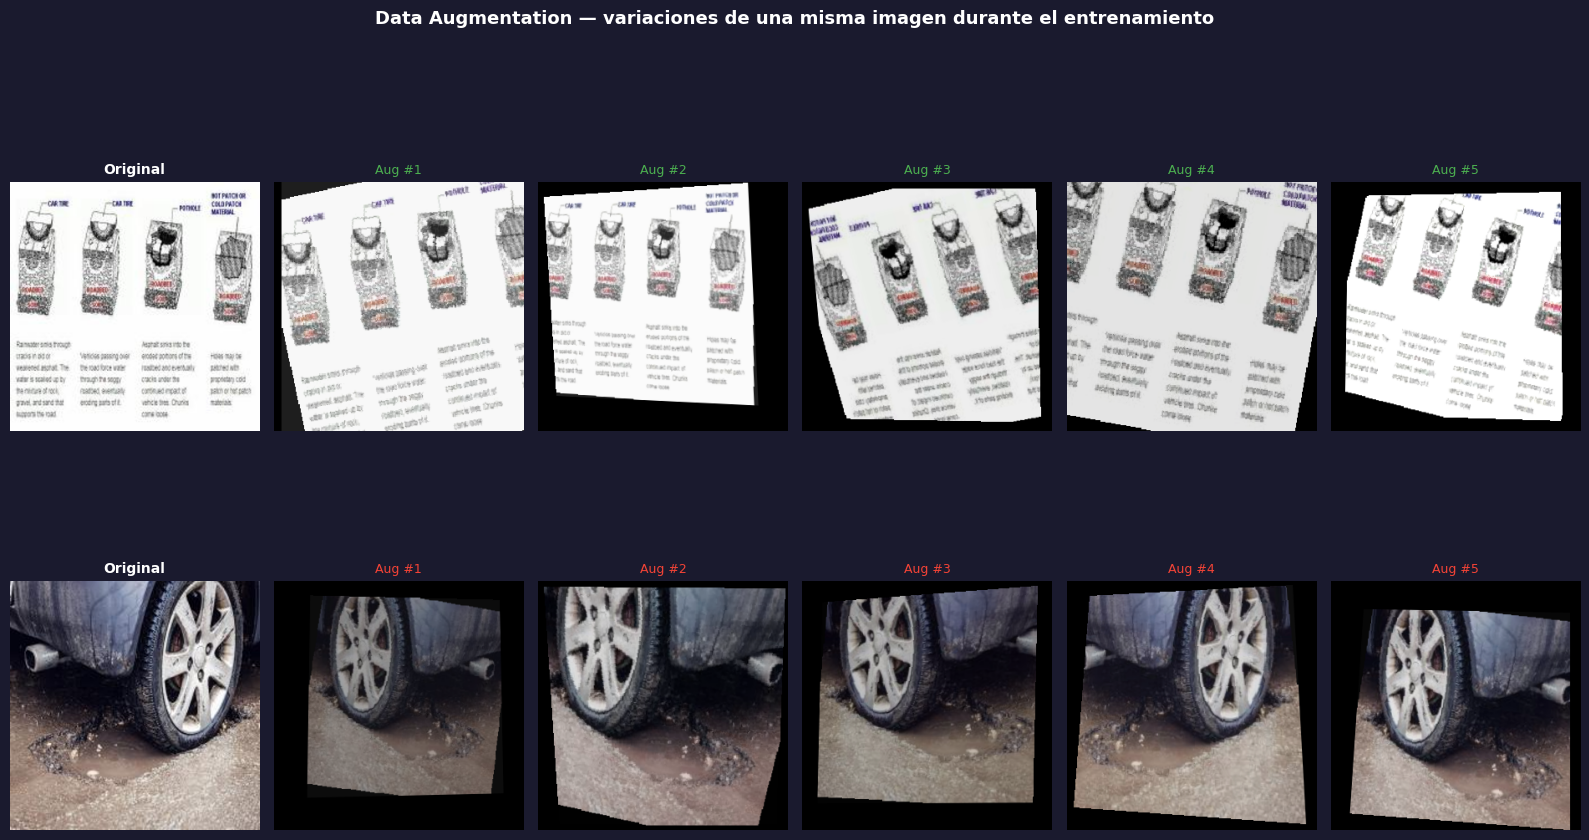

In [47]:
from torchvision import transforms as T

aug_preview = T.Compose([
    T.Resize((299, 299)),
    T.RandomHorizontalFlip(p=0.7),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    T.RandomPerspective(distortion_scale=0.2, p=0.5),
])

n_rows = min(len(info.class_names), 2)
n_aug  = 5  # versiones aumentadas por imagen

fig, axes = plt.subplots(n_rows, n_aug + 1, figsize=(16, 5 * n_rows))
fig.patch.set_facecolor("#1A1A2E")
if n_rows == 1:
    axes = axes.reshape(1, -1)

for row, cls in enumerate(info.class_names[:n_rows]):
    orig_img = ds[split_vis][indices_por_clase[cls][0]][info.image_key].convert("RGB")
    orig_resized = orig_img.resize((299, 299))

    # Columna 0: original
    axes[row][0].imshow(orig_resized)
    axes[row][0].set_title("Original", color="white", fontsize=10, fontweight="bold")
    axes[row][0].axis("off")
    for sp in axes[row][0].spines.values():
        sp.set_edgecolor(CLASS_COLORS[cls]); sp.set_linewidth(3)

    # Columnas 1-5: versiones aumentadas
    for col in range(1, n_aug + 1):
        aug_img = aug_preview(orig_img)
        axes[row][col].imshow(aug_img)
        axes[row][col].set_title(f"Aug #{col}", color=CLASS_COLORS[cls], fontsize=9)
        axes[row][col].axis("off")
        for sp in axes[row][col].spines.values():
            sp.set_edgecolor(CLASS_COLORS[cls]); sp.set_linewidth(1.5)

    axes[row][0].set_ylabel(
        cls, fontsize=12, fontweight="bold", color=CLASS_COLORS[cls]
    )

plt.suptitle(
    "Data Augmentation — variaciones de una misma imagen durante el entrenamiento",
    fontsize=13, fontweight="bold", color="white"
)
plt.tight_layout()
plt.savefig(
    "output/eda_augmentation.png", dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()


### 📋 Resumen del EDA — Hallazgos y Conclusiones

| Análisis | Hallazgo esperado | Implicación para el modelo |
|----------|-------------------|----------------------------|
| **Distribución** | Dataset balanceado (~50/50) | No requiere class weights |
| **Ejemplos visuales** | Alta variabilidad en ángulos e iluminación | Data augmentation es esencial |
| **Imagen promedio** | Huecos con zona central oscura y bordes irregulares | InceptionV3 detectará esta firma |
| **Dimensiones** | Imágenes de tamaños variados | Resize a 299×299 obligatorio |
| **Textura/bordes** | Huecos con mayor densidad de bordes y varianza | CNN usará detectores de textura |
| **Canales RGB** | Huecos con menor intensidad (más oscuros) | Señal fotométrica disponible |
| **Brillo** | Huecos con brillo medio ~5-10% menor | Normalización ImageNet suficiente |
| **Calidad** | Sin corruptas ni duplicados entre splits | Evaluación confiable, sin data leakage |
| **Augmentation** | Transformaciones geométricas + colorimétricas | Reduce overfitting en 200 imágenes |

---

> **Conclusión general:** El dataset `taroii/pothole-detection` está **limpio y bien balanceado**.  
> Las clases son visualmente diferenciables por textura, brillo y densidad de bordes,  
> lo que hace **factible y justificado** el uso de Transfer Learning con InceptionV3.  
> La pequeña cantidad de imágenes (~200 train) exige **data augmentation agresivo**  
> y una estrategia de entrenamiento en dos fases para evitar overfitting.


## 4. Preprocesamiento y DataLoaders

Se redimensionan las imágenes a **299 × 299** (requerido por InceptionV3) y  
se aplica normalización de **ImageNet** (µ y σ de los pesos preentrenados).

**Data augmentation** — solo en train, no en val/test:
- Flip horizontal / vertical
- Rotación ±15°
- Jitter de color (brillo, contraste, saturación)
- Transformación afín (traslación + escala)
- Perspectiva aleatoria

> ⚠️ **Windows:** `num_workers` debe ser **0** en Jupyter para evitar deadlocks.


In [48]:
IMAGE_SIZE   = 299
BATCH_SIZE   = 32
# Windows + Jupyter → num_workers=0 obligatorio
NUM_WORKERS  = 0 if sys.platform.startswith("win") else 2

train_loader, val_loader, test_loader, train_ds, val_ds, test_ds, info = create_dataloaders(
    dataset_name=DATASET_NAME,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

CLASS_NAMES = info.class_names
NUM_CLASSES = info.num_classes

print("Clases          :", CLASS_NAMES)
print(f"Train batches   : {len(train_loader)}  ({len(train_ds)} imágenes)")
print(f"Val batches     : {len(val_loader)}  ({len(val_ds)} imágenes)")
print(f"Test batches    : {len(test_loader)}  ({len(test_ds)} imágenes)")
print(f"num_workers     : {NUM_WORKERS}")


Clases          : ['no pothole', 'pothole']
Train batches   : 7  (200 imágenes)
Val batches     : 6  (165 imágenes)
Test batches    : 3  (72 imágenes)
num_workers     : 0


## 5. Modelo CNN con Transfer Learning

### ¿Por qué Transfer Learning?

Con ~500 imágenes totales, entrenar una CNN desde cero genera **overfitting severo**.  
**InceptionV3** preentrenado en ImageNet (1.2M imágenes, 1000 clases) ya aprendió  
filtros de bajo y alto nivel (bordes, texturas, formas) transferibles a este problema.

### Estrategia de dos fases

1. **Feature Extraction** — backbone congelado, solo se entrena el clasificador final
2. **Fine-tuning** — se descongelas las últimas capas, LR muy bajo para ajuste fino


In [49]:
model = build_pothole_inception(num_classes=NUM_CLASSES, dropout=0.4, feature_extract=True)
model = model.to(DEVICE)

print("Arquitectura   :", model.__class__.__name__)
print(f"Paráms total   : {sum(p.numel() for p in model.parameters()):>12,}")
print(f"Paráms entrena : {count_trainable_parameters(model):>12,}")
print(f"Device         : {DEVICE}")


Arquitectura   : Inception3
Paráms total   :   24,348,900
Paráms entrena :        5,636
Device         : cpu


## 6. Fase 1 — Feature Extraction

Solo el clasificador final (FC layer) tiene gradientes activos.  
LR alto (`1e-3`) porque los pesos del backbone no se mueven.


In [50]:
os.makedirs("models", exist_ok=True)

EPOCHS_PHASE1 = 5
LR_PHASE1     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
)

print("=" * 45)
print("  FASE 1: Feature Extraction")
print("=" * 45)
train_losses_p1, val_losses_p1, train_accs_p1, val_accs_p1 = train_model(
    model=model,
    model_name="pothole_inception_phase1",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS_PHASE1,
)


  FASE 1: Feature Extraction

Epoch 1/5
----------------------------------------


Train Loss: 0.8741 | Train Acc: 57.50%
Val Loss:   0.6955 | Val Acc:   50.91%
Mejor modelo guardado: models\pothole_inception_phase1_best.pth

Epoch 2/5
----------------------------------------


Train Loss: 0.6159 | Train Acc: 79.50%
Val Loss:   0.5219 | Val Acc:   78.18%
Mejor modelo guardado: models\pothole_inception_phase1_best.pth

Epoch 3/5
----------------------------------------


Train Loss: 0.4662 | Train Acc: 85.50%
Val Loss:   0.6093 | Val Acc:   74.55%

Epoch 4/5
----------------------------------------


Train Loss: 0.3950 | Train Acc: 90.50%
Val Loss:   0.5581 | Val Acc:   76.36%

Epoch 5/5
----------------------------------------


Train Loss: 0.3359 | Train Acc: 92.50%
Val Loss:   0.5645 | Val Acc:   76.97%


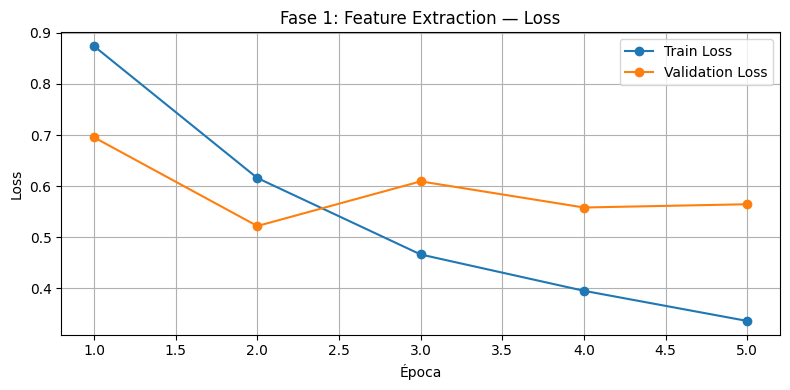

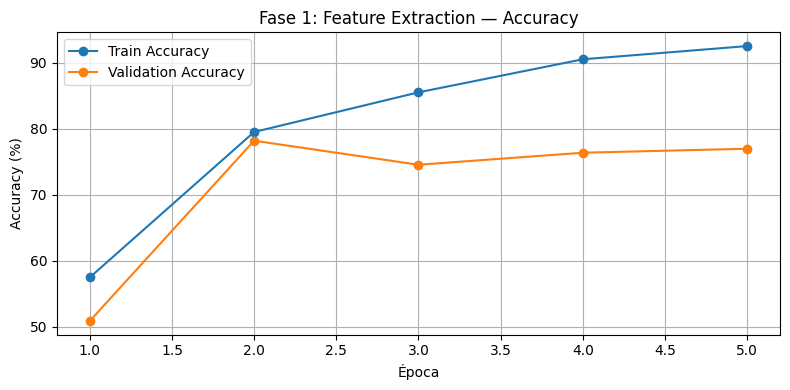

Test Loss Fase 1 : 0.5560
Test Accuracy    : 75.00%


In [51]:
plot_training_curves(
    train_losses_p1, val_losses_p1,
    train_accs_p1,   val_accs_p1,
    title="Fase 1: Feature Extraction",
    save_path="output/curves_phase1.png",
)

test_loss_p1, test_acc_p1 = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test Loss Fase 1 : {test_loss_p1:.4f}")
print(f"Test Accuracy    : {test_acc_p1:.2f}%")


## 7. Fase 2 — Fine-tuning

Se descongelas las últimas 40 capas/parámetros del backbone.  
LR bajo (`1e-4`) para no destruir los pesos aprendidos en ImageNet.


In [52]:
model = unfreeze_last_layers(model, num_layers=40)
print("Paráms entrenables tras fine-tuning:", count_trainable_parameters(model))

EPOCHS_PHASE2 = 6
LR_PHASE2     = 1e-4

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2,
)

print("=" * 45)
print("  FASE 2: Fine-tuning")
print("=" * 45)
train_losses_p2, val_losses_p2, train_accs_p2, val_accs_p2 = train_model(
    model=model,
    model_name="pothole_inception_finetune",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    device=DEVICE,
    epochs=EPOCHS_PHASE2,
)


Paráms entrenables tras fine-tuning: 7215620
  FASE 2: Fine-tuning

Epoch 1/6
----------------------------------------


Train Loss: 0.4082 | Train Acc: 89.50%
Val Loss:   0.5463 | Val Acc:   81.21%
Mejor modelo guardado: models\pothole_inception_finetune_best.pth

Epoch 2/6
----------------------------------------


Train Loss: 0.2265 | Train Acc: 96.00%
Val Loss:   0.6984 | Val Acc:   80.00%

Epoch 3/6
----------------------------------------


Train Loss: 0.1870 | Train Acc: 97.50%
Val Loss:   0.8598 | Val Acc:   80.00%

Epoch 4/6
----------------------------------------


Train Loss: 0.1168 | Train Acc: 99.50%
Val Loss:   0.9167 | Val Acc:   80.00%

Epoch 5/6
----------------------------------------


Train Loss: 0.0976 | Train Acc: 99.50%
Val Loss:   0.9177 | Val Acc:   80.00%

Epoch 6/6
----------------------------------------


Train Loss: 0.1160 | Train Acc: 99.00%
Val Loss:   0.9464 | Val Acc:   80.61%


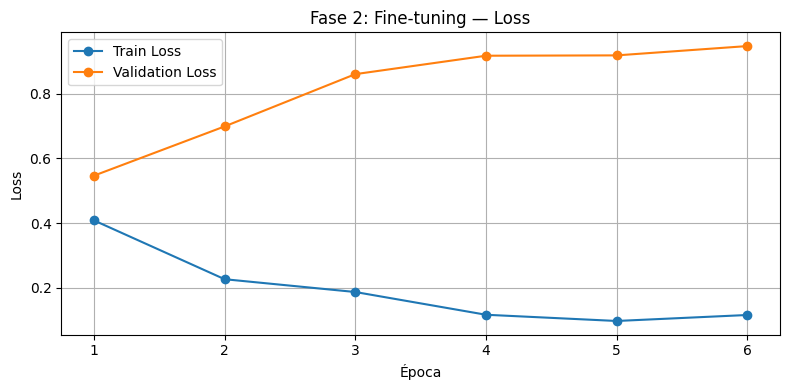

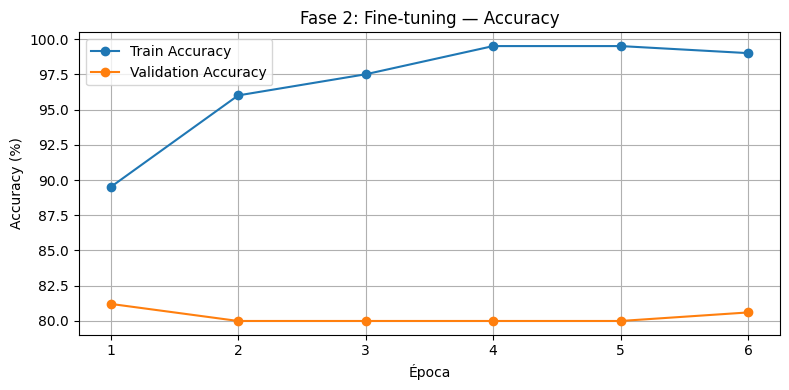

Test Loss Fase 2 : 0.6977
Test Accuracy    : 75.00%
Mejora vs Fase 1 : +0.00 pp


In [53]:
plot_training_curves(
    train_losses_p2, val_losses_p2,
    train_accs_p2,   val_accs_p2,
    title="Fase 2: Fine-tuning",
    save_path="output/curves_phase2.png",
)

test_loss_p2, test_acc_p2 = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test Loss Fase 2 : {test_loss_p2:.4f}")
print(f"Test Accuracy    : {test_acc_p2:.2f}%")
print(f"Mejora vs Fase 1 : +{test_acc_p2 - test_acc_p1:.2f} pp")


## 8. Evaluación Final

Se calculan métricas por clase, matriz de confusión y ejemplos visuales  
de predicciones correctas e incorrectas del modelo.

**Métricas usadas:**
- **Accuracy** — porcentaje de predicciones correctas (sensible al desbalanceo)
- **Precision** — de las predicciones positivas, cuántas son realmente positivas
- **Recall** — de los verdaderos positivos, cuántos fueron detectados
- **F1-score** — media armónica de precision y recall (balance entre ambas)


In [54]:
metrics = classification_metrics(model, test_loader, DEVICE, class_names=CLASS_NAMES)

print(f"Accuracy          : {metrics['accuracy']:.2f}%")
print(f"Precision (w)     : {metrics['precision_weighted']:.4f}")
print(f"Recall (w)        : {metrics['recall_weighted']:.4f}")
print(f"F1-score (w)      : {metrics['f1_weighted']:.4f}")
print("\nClassification report:")
print(metrics["classification_report"])


Accuracy          : 75.00%
Precision (w)     : 0.8325
Recall (w)        : 0.7500
F1-score (w)      : 0.7531

Classification report:
              precision    recall  f1-score   support

  no pothole       0.60      0.96      0.74        26
     pothole       0.97      0.63      0.76        46

    accuracy                           0.75        72
   macro avg       0.78      0.80      0.75        72
weighted avg       0.83      0.75      0.75        72



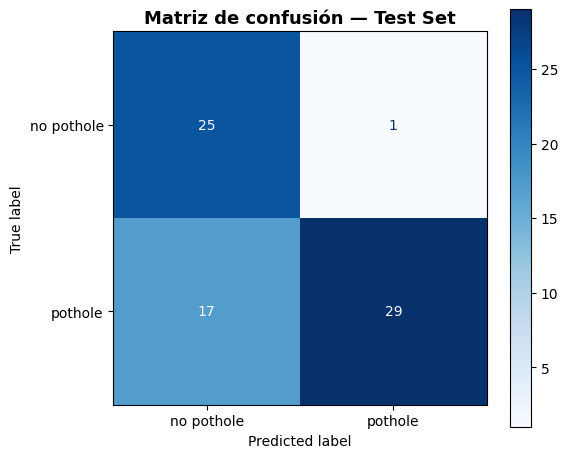

In [55]:
plot_confusion_matrix(
    metrics["confusion_matrix"],
    CLASS_NAMES,
    save_path="output/confusion_matrix.png",
)


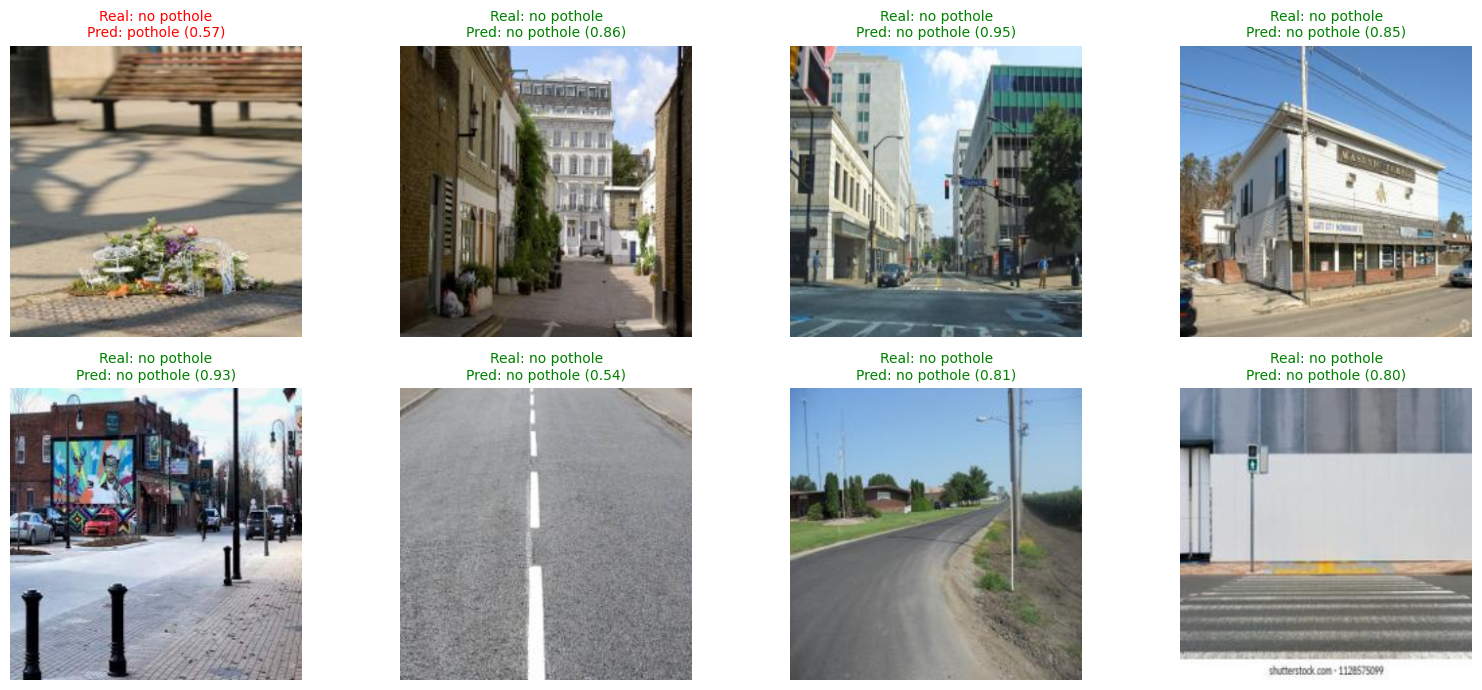

In [56]:
show_predictions(
    model=model,
    dataloader=test_loader,
    device=DEVICE,
    class_names=CLASS_NAMES,
    n=8,
    save_path="output/predictions.png",
)


## 9. Grad-CAM — Explicabilidad

**Grad-CAM** (*Gradient-weighted Class Activation Mapping*) visualiza qué zonas  
de la imagen activaron más la predicción del modelo.

Esto permite verificar si el modelo:
- ✅ Mira la **zona del hueco** (comportamiento correcto)
- ❌ Se guía por señales espurias como sombras, bordes de imagen o textura de fondo

Para InceptionV3 se usa la capa `Mixed_7c` (última capa convolucional profunda).


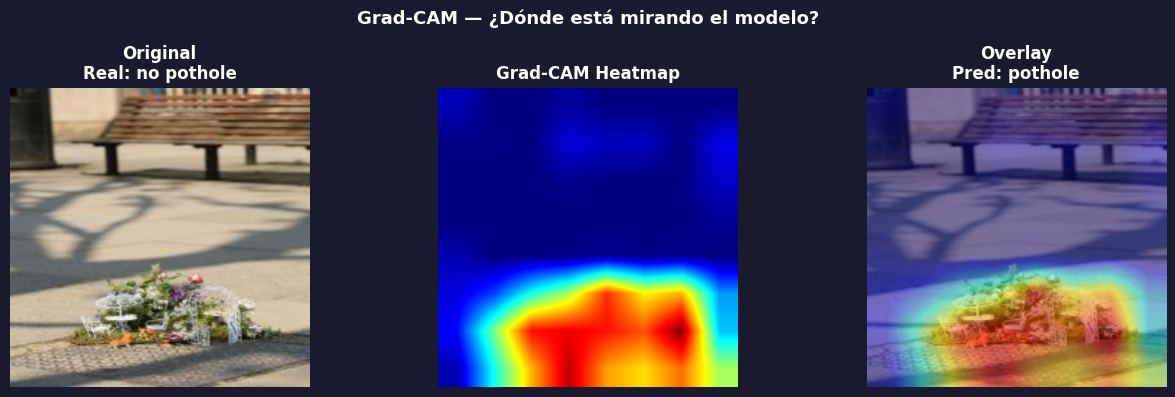

In [57]:
model.eval()
if hasattr(model, "aux_logits"):
    model.aux_logits = False

images, labels = next(iter(test_loader))
image      = images[0].unsqueeze(0).to(DEVICE)
image.requires_grad_(True)
true_label = int(labels[0])

capture, remove = attach_hooks(model, "Mixed_7c")
output, pred    = run_forward(model, image)
run_backward(output, pred)
cam = compute_gradcam(capture["act"], capture["grad"])
cam = resize_cam(cam, images[0].shape[1], images[0].shape[2])
remove()

from src.utils import unnormalize
orig      = unnormalize(images[0])
orig_uint8 = (orig * 255).astype(np.uint8)
cam_np    = cam.detach().cpu().numpy()
overlay, heatmap = overlay_cam(orig_uint8, cam_np)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor("#1A1A2E")
for ax in axes:
    ax.set_facecolor("#1A1A2E")

axes[0].imshow(orig_uint8)
axes[0].set_title(f"Original\nReal: {CLASS_NAMES[true_label]}",
                   color="white", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(heatmap)
axes[1].set_title("Grad-CAM Heatmap", color="white", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay\nPred: {CLASS_NAMES[pred]}",
                   color="white", fontweight="bold")
axes[2].axis("off")

plt.suptitle("Grad-CAM — ¿Dónde está mirando el modelo?",
             fontsize=13, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig("output/gradcam_example.png", bbox_inches="tight", dpi=140,
            facecolor=fig.get_facecolor())
plt.show()
